In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler



In [24]:
df_obras = pd.read_csv('../../db/clean/df_cluster.csv')


In [25]:
cols_numericas = ['publico_total', 'qtd_sessoes', 'dias_cartaz', 'renda_total']
cols_booleanas = ['investimento_fsa', 'coproducao', 'fomento_indireto',
                  'independente', 'curta_metragem', 'longa_metragem',
                  'media_metragem', 'animacao', 'documentario',
                  'ficcao', 'variedades', 'videomusical'
                  ]
scaler = StandardScaler()
df_obras[cols_numericas] = scaler.fit_transform(df_obras[cols_numericas])
obras = df_obras.copy()

## Método do cotovelo

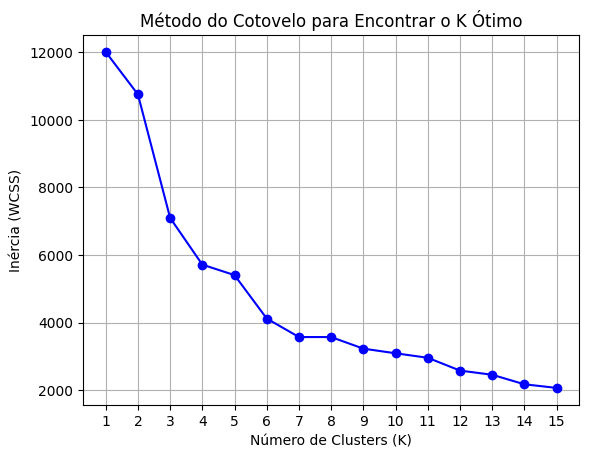

In [26]:
# Implementando o Método do Cotovelo com visualização iterativa
k_range = range(1, 16)
inertias = []
clustering_results = []

for k in k_range:
    model = KMeans(n_clusters=k, max_iter=150, random_state=42)
    model.fit(obras)

    inertias.append(model.inertia_)
    clustering_results.append({'labels': model.labels_, 'centroids': model.cluster_centers_})

# Plotar o gráfico do cotovelo
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo para Encontrar o K Ótimo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

## Visualização do k-means com PCA

Text(0.5, 1.0, 'Visualização do agrupamento com k-means (Visualização PCA)')

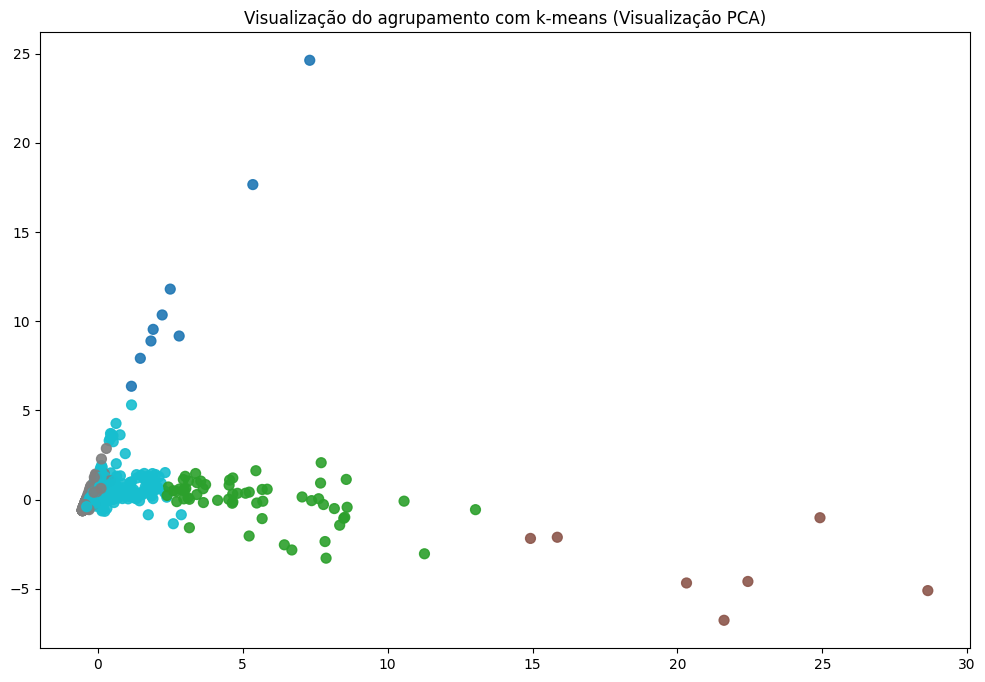

In [27]:
# k-means com PCA
kmeans = KMeans(n_clusters=5, random_state=0, n_init=10, init='k-means++').fit(obras)
labels = kmeans.labels_
clusters_kmeans = kmeans.predict(obras)
pca = PCA(n_components=8)
X_visualizacao = pca.fit_transform(obras)
# obras['cluster_kmeans'] = clusters_kmeans
plt.figure(figsize=(12, 8))
# sns.scatterplot(data=obras, x='publico_total', y= 'dias_cartaz', hue=clusters_kmeans, palette='tab10')
plt.scatter(X_visualizacao[:, 0], X_visualizacao[:, 1],
            c=labels,            # Define a cor de acordo com o grupo
            cmap='tab10',      # Paleta de cores
            s=50,                # Tamanho da bolinha
            alpha=0.9)           # Transparência (ajuda a ver sobreposição)

plt.title("Visualização do agrupamento com k-means (Visualização PCA)")

## Dendograma

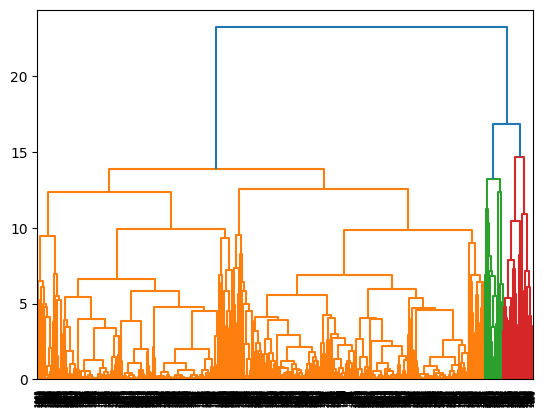

In [28]:
# obtendo medida de distância baseada no cosseno
similarity_distance = 1 - cosine_similarity(obras)

# computa a sequência de grupos unidos usando a ligação média
mergings = linkage(similarity_distance, method='average')

# configura o dendrograma
dendrogram_ = dendrogram(mergings,
               leaf_rotation=90
)

## Observando os pontos nos centros de cada cluster

In [29]:
km = KMeans(n_clusters=5, random_state=0, n_init=10, init='k-means++')
km.fit(obras)
centers = km.cluster_centers_
df_centros = pd.DataFrame(centers, columns=df_obras.columns)
df_centros[cols_numericas] = scaler.inverse_transform(df_centros[cols_numericas])
df_centros['cluster'] = range(len(df_centros))
display(df_centros.round().astype(int))

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,0,0,1,40039,5746,1073,742348,1,0,1,0,0,0,1,0,0,0
1,0,0,1,1835956,14008,100,23356101,1,0,1,0,0,0,1,0,0,1
2,0,0,1,8455294,33447,137,116592759,1,0,1,0,0,0,1,0,0,2
3,0,0,0,2544,101,28,35107,1,0,1,0,0,1,0,0,0,3
4,1,0,0,34926,797,42,474450,1,0,1,0,0,0,1,0,0,4


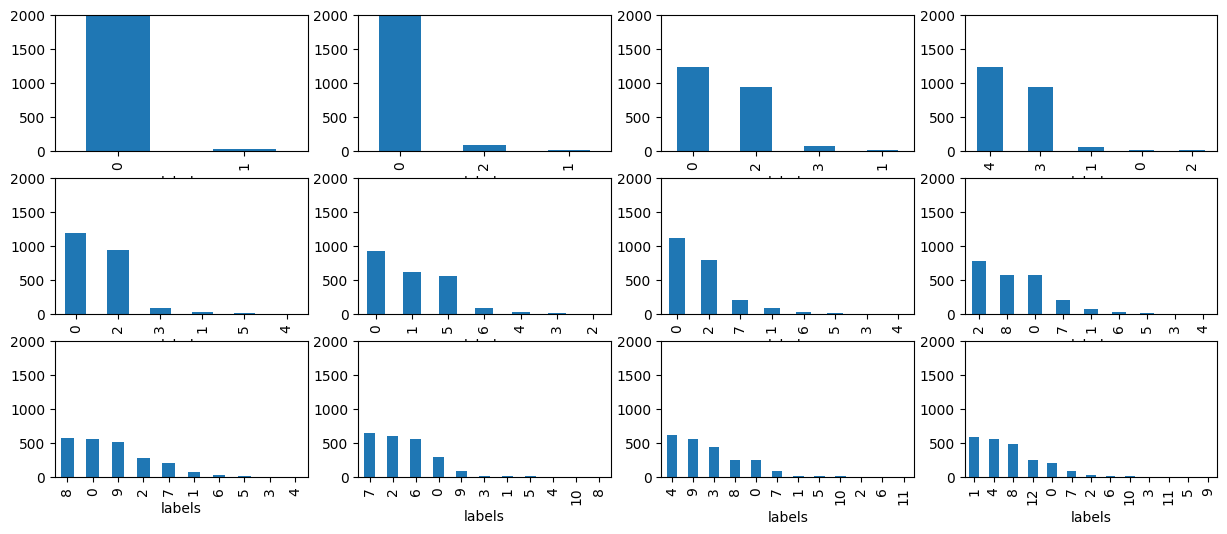

In [30]:
# configuração do gráfico que vai ser gerado
fig, axs = plt.subplots(3,4, figsize=(15, 6), facecolor='w', edgecolor='k')
axs = axs.ravel()

# dataframe para armazenar os dados
df = pd.DataFrame()

# intervalo com a quantidade de grupos que vamos dividir os dados
ks = range(2, 14)
for k in ks:
  km = KMeans(n_clusters=k, random_state=0, n_init=10, init='k-means++').fit(obras)
  labels = km.labels_.tolist()
  # cria um dataframe para facilitar a contagem dos objetos em cada grupo
  df['labels'] = labels
  # plota a quantidade de objetos em cada grupo
  df['labels'].value_counts().plot(kind='bar',ax=axs[k-2],ylim=(0,2000))

### Comparativo com quantidades diversas de grupos

In [31]:
ks = range(6, 15)
for k in ks:
  km = KMeans(n_clusters=k, random_state=0, n_init=10, init='k-means++')
  km.fit(obras)
  # Contagem de registros por cluster
  contagem = pd.Series(km.labels_).value_counts()
  print(contagem)
  # ---
  centers = km.cluster_centers_
  df_centros = pd.DataFrame(centers, columns=df_obras.columns)
  df_centros[cols_numericas] = scaler.inverse_transform(df_centros[cols_numericas])
  df_centros['cluster'] = range(len(df_centros))
  display(df_centros.round().astype(int))

0    1186
2     934
3      91
1      23
5       9
4       5
Name: count, dtype: int64


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,1,0,0,19772,506,39,257536,1,0,1,0,0,0,1,0,0,0
1,0,0,1,3442884,16581,105,44084342,1,0,1,0,0,0,1,0,0,1
2,0,0,0,2549,101,28,35188,1,0,1,0,0,1,0,0,0,2
3,0,0,1,663005,10009,92,9165877,1,0,1,0,0,0,1,0,0,3
4,0,0,0,9902008,33309,158,130003803,1,0,1,0,0,0,1,0,0,4
5,0,0,1,40039,5746,1073,742348,1,0,1,0,0,0,1,0,0,5


0    929
1    624
5    565
6     92
4     24
3      9
2      5
Name: count, dtype: int64


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,0,0,0,2553,100,28,35174,1,0,1,0,0,1,0,0,0,0
1,1,0,1,23650,601,42,309967,1,0,1,0,0,0,1,0,0,1
2,0,0,0,9902008,33309,158,130003803,1,0,1,0,0,0,1,0,0,2
3,0,0,1,40039,5746,1073,742348,1,0,1,0,0,0,1,0,0,3
4,0,0,1,3392671,16368,105,43281980,1,0,1,0,0,0,1,0,0,4
5,0,0,0,14647,391,35,186806,1,0,1,0,0,0,1,0,0,5
6,0,0,1,636112,9840,97,8868783,1,0,1,0,0,0,1,0,0,6


0    1123
2     789
7     207
1      91
6      23
5       8
3       5
4       2
Name: count, dtype: int64


...

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,1,0,0,2710,169,33,37724,1,0,1,0,0,0,1,0,0,0
1,0,0,1,2554470,24408,125,37973150,1,0,1,0,0,0,1,0,0,1
2,0,0,0,10913184,23210,151,132950717,0,0,1,0,0,0,1,0,0,2
3,0,0,0,6470,176,26,84542,1,0,1,0,0,0,1,0,0,3
4,0,0,0,2788,95,28,35568,1,0,1,0,0,1,0,0,0,4
5,0,0,0,22669,1821,599,405873,1,0,1,0,0,0,1,0,0,5
6,1,0,1,90518,15680,1872,1605126,1,0,1,0,0,0,1,0,0,6
7,1,0,1,649772,9307,90,8889420,1,0,1,0,0,0,1,0,0,7
8,1,0,0,2357,148,31,35630,1,0,1,0,0,1,0,0,0,8
9,1,0,1,32782,854,45,434021,1,0,1,0,0,0,1,0,0,9


1     592
4     559
8     489
12    248
0     205
7      90
2      27
6      16
10     11
3       4
11      4
5       2
9       1
Name: count, dtype: int64


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,0,0,0,699,52,22,12296,1,0,0,1,0,0,0,0,0,0
1,1,0,1,18004,547,40,242492,1,0,1,0,0,0,1,0,0,1
2,0,0,1,1570584,17943,122,21877902,1,0,1,0,0,0,1,0,0,2
3,0,0,0,10913184,23210,151,132950717,0,0,1,0,0,0,1,0,0,3
4,0,0,0,3122,100,28,41434,1,0,1,0,0,1,0,0,0,4
5,1,0,1,90518,15680,1872,1605126,1,0,1,0,0,0,1,0,0,5
6,0,0,0,24166,1742,581,408554,1,0,1,0,0,0,1,0,0,6
7,1,0,1,475505,7535,85,6478280,1,0,1,0,0,0,1,0,0,7
8,0,0,0,13303,365,34,165223,1,0,1,0,0,0,1,0,0,8
9,0,1,0,5857306,73704,185,118216149,1,0,1,0,0,0,1,0,0,9


2     537
0     436
6     354
11    302
8     265
5     206
9      95
7      25
1       9
10      8
12      4
4       4
3       2
13      1
Name: count, dtype: int64


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,1,0,1,3417,124,31,45558,1,0,1,0,0,1,0,0,0,0
1,0,0,1,4230575,3760,62,44500339,1,0,1,0,0,0,1,0,0,1
2,1,0,1,26079,739,44,342455,1,0,1,0,0,0,1,0,0,2
3,1,0,1,90518,15680,1872,1605126,1,0,1,0,0,0,1,0,0,3
4,0,0,1,3891563,35777,91,66447438,1,0,1,0,0,0,1,0,0,4
5,0,0,0,758,56,25,13495,1,0,0,1,0,0,0,0,0,5
6,0,0,0,2217,92,26,31720,1,0,1,0,0,1,0,0,0,6
7,0,0,1,1857894,18194,125,25308795,1,0,1,0,0,0,1,0,0,7
8,1,0,0,2881,193,37,40968,1,0,1,0,0,0,1,0,0,8
9,1,0,1,477202,7775,92,6569164,1,0,1,0,0,0,1,0,0,9
